#### Load the Annual Car Population by Make from data.gov.sg

In [1]:
import pandas as pd

df = pd.read_csv("AnnualCarPopulationbyMake.csv")

print(df.tail())

      year      make fuel_type  number
1938  2024  WOLSELEY    Petrol     2.0
1939  2024    WULING    Petrol     NaN
1940  2024     XPENG  Electric   336.0
1941  2024     ZEEKR  Electric    99.0
1942  2024     ZOTYE    Petrol     1.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1943 entries, 0 to 1942
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       1943 non-null   int64  
 1   make       1943 non-null   object 
 2   fuel_type  682 non-null    object 
 3   number     1894 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 60.8+ KB


In [3]:
df["year"]

0       2005
1       2005
2       2005
3       2005
4       2005
        ... 
1938    2024
1939    2024
1940    2024
1941    2024
1942    2024
Name: year, Length: 1943, dtype: int64

In [13]:
df["fuel_type"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1938      Petrol
1939      Petrol
1940    Electric
1941    Electric
1942      Petrol
Name: fuel_type, Length: 1943, dtype: object

In [ ]:
# Take note for EV, it includes "Petrol-Electric (Plug-In)", "Electric" and "Diesel-Electric (Plug-In)" 
# The classification of fuel type starts from YR2022 onwards.

df["fuel_type"].unique()

array([nan, 'Petrol', 'Diesel', 'Petrol-Electric',
       'Petrol-Electric (Plug-In)', 'Electric', 'Diesel-Electric',
       'Petrol-CNG', 'Diesel-Electric (Plug-In)'], dtype=object)

In [ ]:
# Check number of fuel_type: "Diesel-Electric (Plug-In)", not popular, basically it can be ignored.

ev_diesel_by_year = (
    df[df["fuel_type"] == "Diesel-Electric (Plug-In)"]   # fuel_type: Electric & Petrol-Electric (Plug-In) - refer above
    .groupby("year")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)

print(ev_diesel_by_year)

   year  count
0  2022      1
1  2023      1
2  2024      1


In [29]:
ev_df = df[
    df["fuel_type"].isin([
        "Electric",
        "Petrol-Electric (Plug-In),"
        "Diesel-Electric (Plug-In)"
    ])
]

print(ev_df)

      year        make fuel_type  number
1272  2022        AUDI  Electric   163.0
1281  2022      B.M.W.  Electric   636.0
1288  2022     BLUECAR  Electric   791.0
1290  2022         BYD  Electric   984.0
1312  2022        FIAT  Electric     1.0
...    ...         ...       ...     ...
1923  2024      TOYOTA  Electric    94.0
1932  2024  VOLKSWAGEN  Electric   200.0
1937  2024       VOLVO  Electric   541.0
1940  2024       XPENG  Electric   336.0
1941  2024       ZEEKR  Electric    99.0

[93 rows x 4 columns]


In [30]:
ev_by_year = (
    ev_df   # fuel_type: Electric & Petrol-Electric (Plug-In) - refer above
    .groupby("year")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)

print(ev_by_year)

   year  count
0  2022   6569
1  2023  12018
2  2024  26339


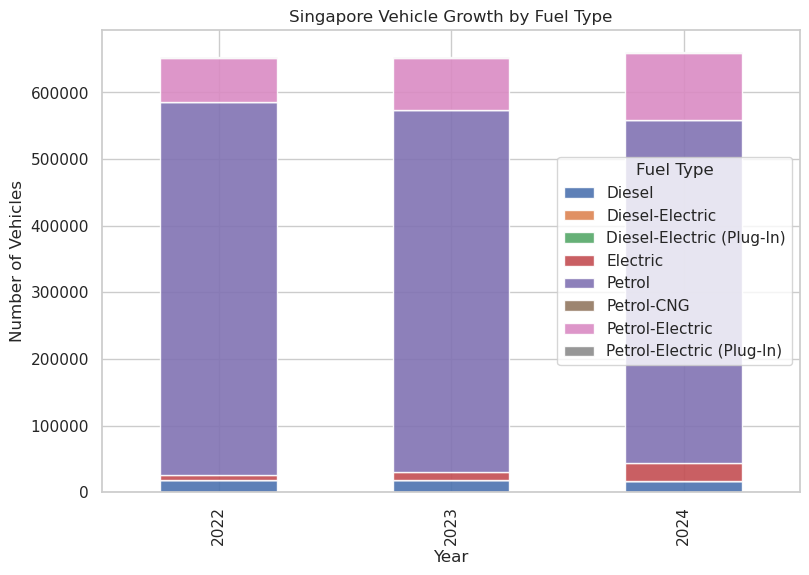

In [31]:
import matplotlib.pyplot as plt

# Group by year and fuel type
vehicle_by_year = (
    df.groupby(["year", "fuel_type"])["number"]
    .sum()
    .unstack(fill_value=0)
)

# Stacked area chart
vehicle_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    alpha=0.9
)

plt.xlabel("Year")
plt.ylabel("Number of Vehicles")
plt.title("Singapore Vehicle Growth by Fuel Type")
plt.legend(title="Fuel Type")
plt.show()

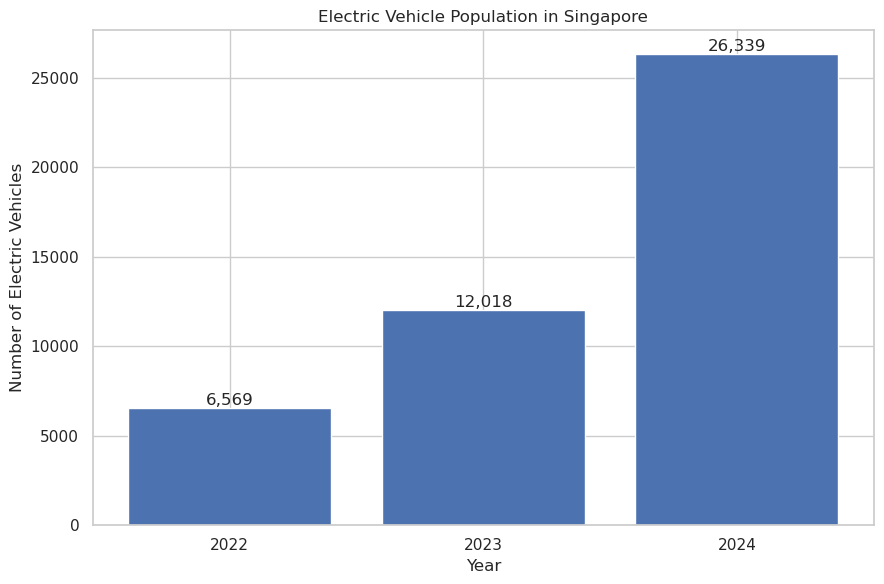

In [32]:
import matplotlib.pyplot as plt

ev = (
    ev_df
    .groupby("year")["number"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    ev["year"].astype(str),
    ev["number"]
)

plt.xlabel("Year")
plt.ylabel("Number of Electric Vehicles")
plt.title("Electric Vehicle Population in Singapore")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

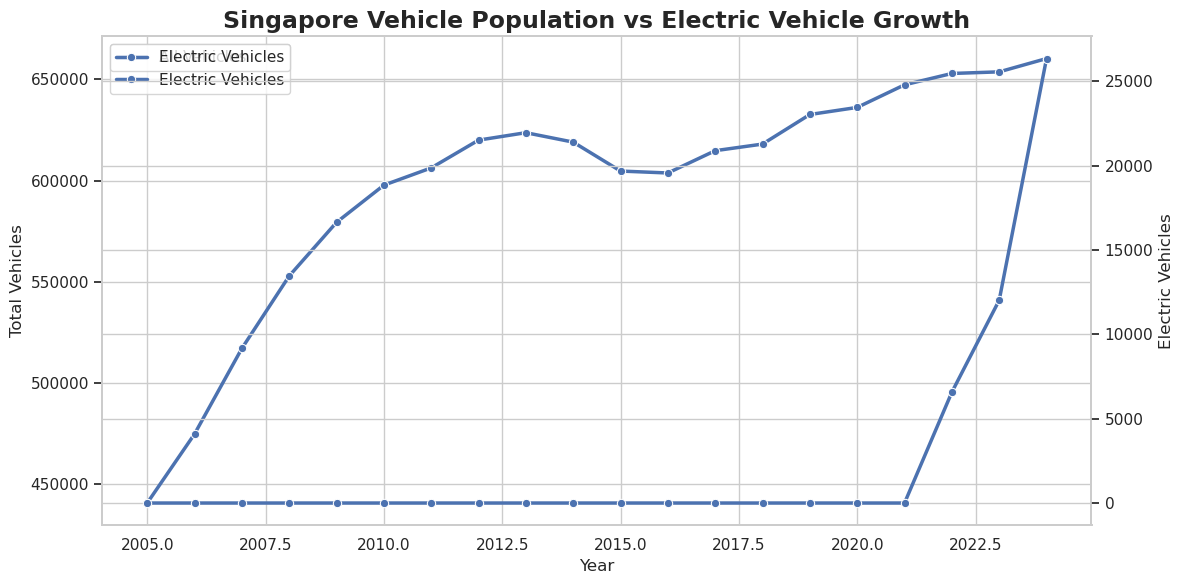

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# All vehicles by year
all_vehicles = (
    df[df["year"] >= 2005]
    .groupby("year")["number"]
    .sum()
    .reset_index(name="total_vehicles")
)

# Electric vehicles by year
electric_vehicles = (
    df[
        (df["year"] >= 2005) &
        (df["fuel_type"] == "Electric")
    ]
    .groupby("year")["number"]
    .sum()
    .reset_index(name="electric_vehicles")
)

# Combine datasets
plot_df = pd.merge(
    all_vehicles,
    electric_vehicles,
    on="year",
    how="left"
)

# Replace missing EV values with 0
plot_df["electric_vehicles"] = plot_df["electric_vehicles"].fillna(0)

# Plot
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# All vehicles
sns.lineplot(
    data=plot_df,
    x="year",
    y="total_vehicles",
    marker="o",
    linewidth=2.5,
    ax=ax1,
    label="All Vehicles"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Vehicles")

# Second Y-axis for EV
ax2 = ax1.twinx()

sns.lineplot(
    data=plot_df,
    x="year",
    y="electric_vehicles",
    marker="o",
    linewidth=2.5,
    ax=ax2,
    label="Electric Vehicles"
)

ax2.set_ylabel("Electric Vehicles")

# Title
plt.title(
    "Singapore Vehicle Population vs Electric Vehicle Growth",
    fontsize=17,
    fontweight="bold"
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()